# Imports

In [193]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta


# Import the basal Ganglia model 
%load_ext autoreload
%autoreload 2
from bg_model import BasalGanglia
%load_ext autoreload
%autoreload 2
from utility import Utility

# Reload

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Bundle Creation & Scaling

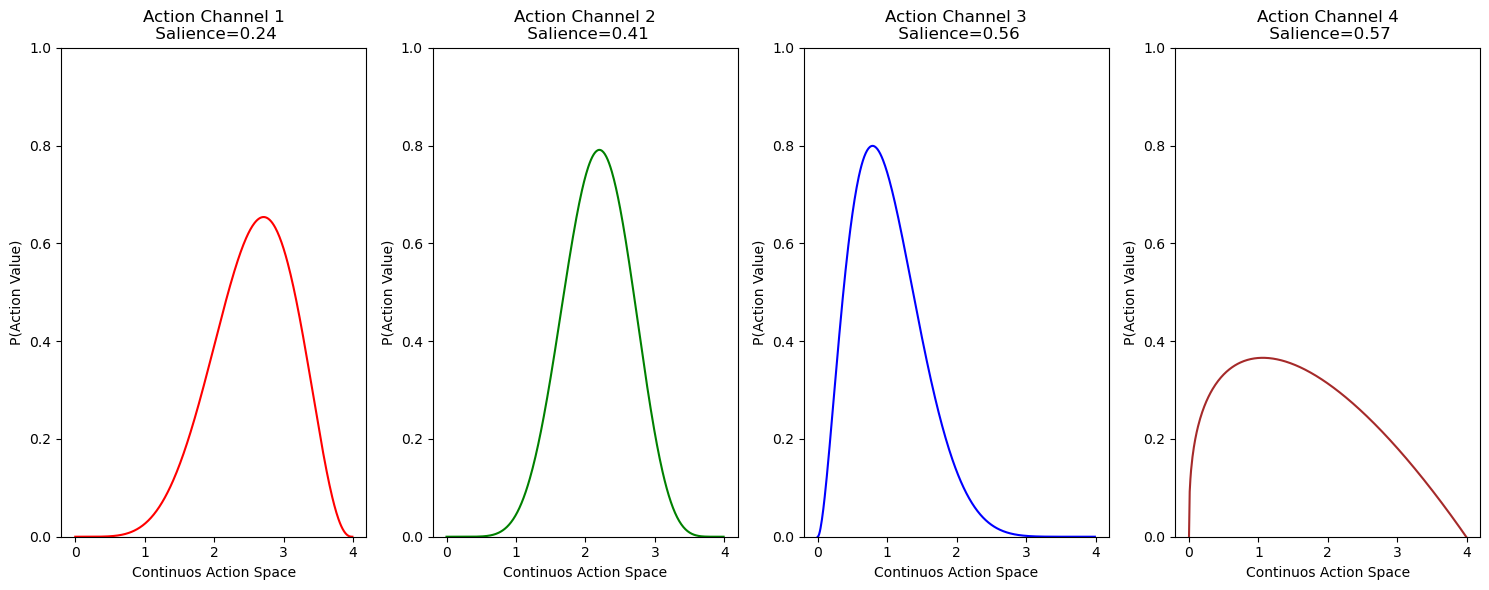

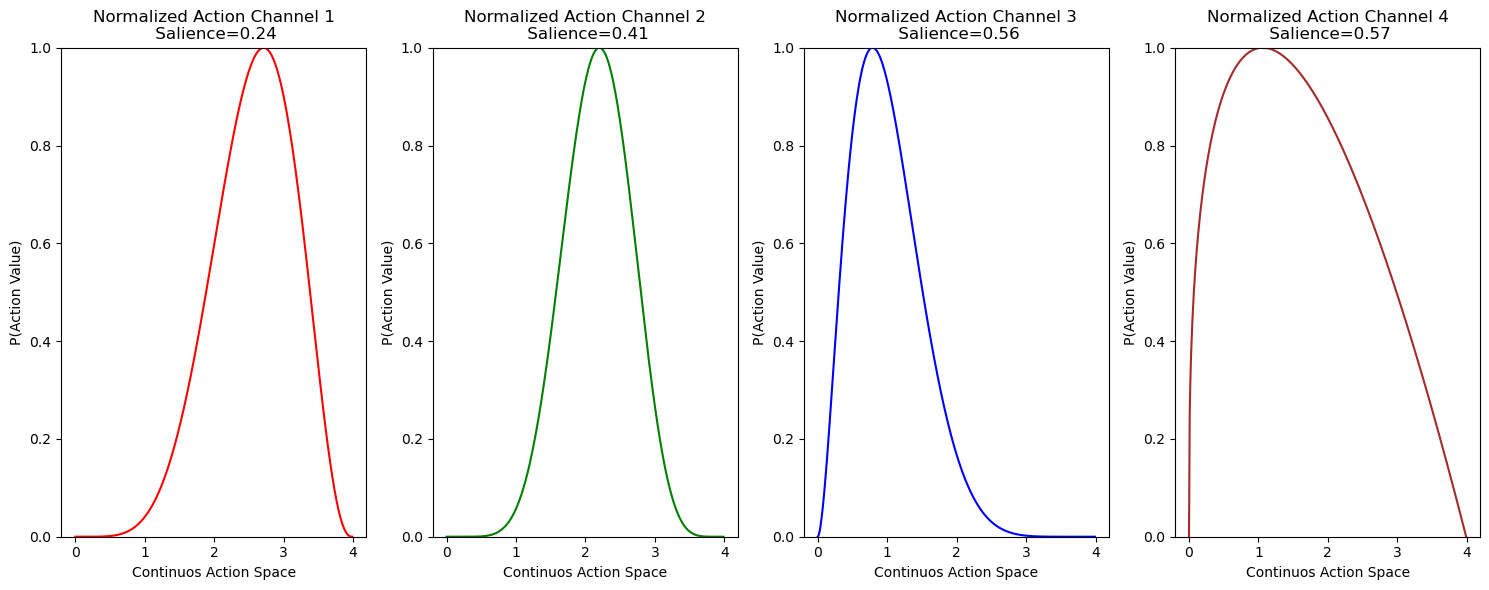

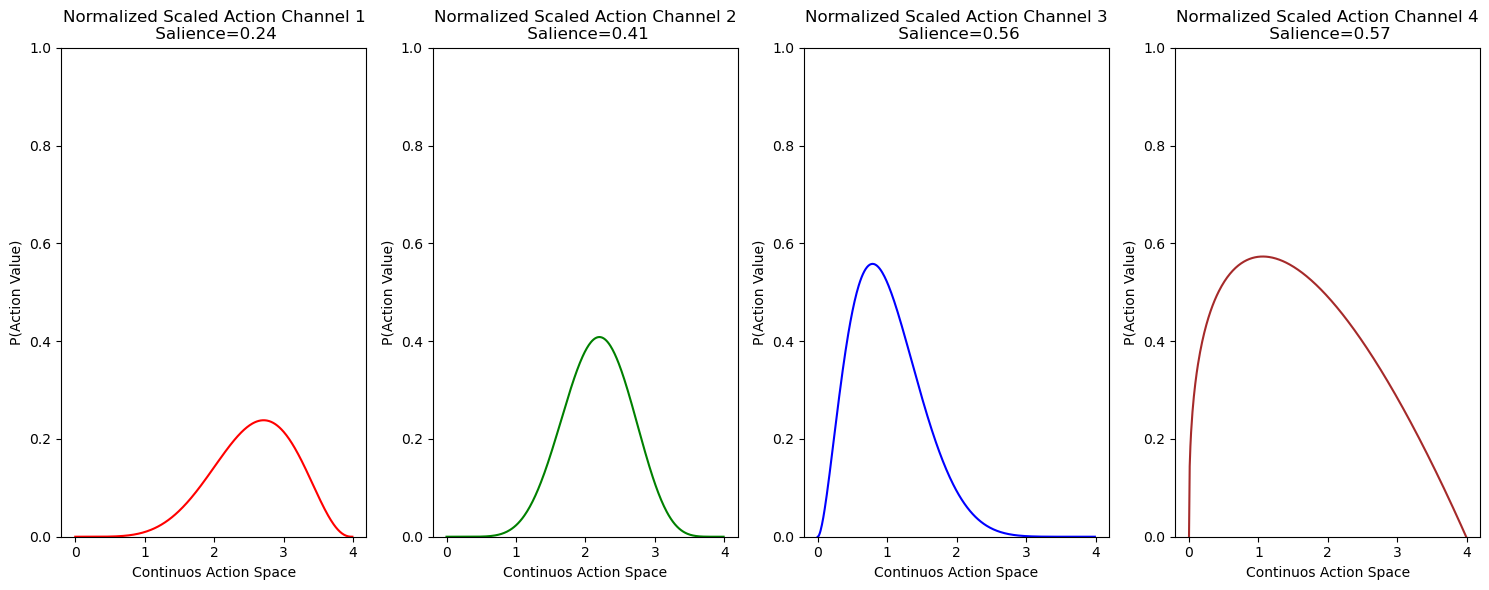

In [194]:
# Domain:  [0, 4]
domain = np.arange(0, 4, 0.01).reshape(-1, 1) # Shape: (400, 1)
# from sspspace.encoders import RandomSSPSpace  
from sspspace.sspspace.encoders import RandomSSPSpace
# SSP encoder
ssp_encoder = RandomSSPSpace(
    domain_dim = 1, # scalar action values
    ssp_dim = 512, # high dimensional SSPs
    rng=np.random.RandomState(), 
    length_scale=0.5
)

# Convert scalar action values into high dimensional SSPs
domain_phis = ssp_encoder.encode(domain) # Shape: (400, 512)

# Place cell encoders for Nengo ensembles
low = 0
high = 4
width = high - low
places_ = np.arange(low, high, width/(domain.shape[0]))
encoders = np.asarray(ssp_encoder.encode(places_.reshape(-1, 1))).squeeze()

# Create distributions 
n_actions = 4 # Number of action channels in the BG model 
seed = 20889604
rng = np.random.RandomState(seed)
# Randomly sample a's and b's to create distributions 
a_s = np.random.uniform(low = 1, high = 10, size = n_actions)
b_s = np.random.uniform(low = 1, high = 10, size = n_actions)

beta_distributions = []

for i in range(n_actions):
    # Beta PDF over domain 
    beta_pdfs = beta.pdf(domain, a_s[i], b_s[i], scale=domain[-1]) # Shape: (400, 1)
    beta_distributions.append(beta_pdfs)

# Scale by salience
salience = np.random.uniform(low = 0, high = 1, size = n_actions)

# Plot the Distributions
colors = ['red', 'green', 'blue', 'brown']
fig, axs = plt.subplots(1, n_actions, figsize=(15, 6))
for i in range(n_actions):
    axs[i].plot(domain, beta_distributions[i], color=colors[i])
    axs[i].set_title(f'Action Channel {i + 1}\n Salience={salience[i]:.2f}', fontsize=12)
    axs[i].set_xlabel("Continuos Action Space")
    axs[i].set_ylabel("P(Action Value)")
    axs[i].set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Plot the normalized version of the distributions
normalized_distributions = Utility.to_normalize(beta_distributions)
fig, axs = plt.subplots(1, n_actions, figsize=(15, 6))
for i in range(n_actions):
    axs[i].plot(domain, normalized_distributions[i], color=colors[i])
    axs[i].set_title(f'Normalized Action Channel {i + 1}\n Salience={salience[i]:.2f}', fontsize=12)
    axs[i].set_xlabel("Continuos Action Space")
    axs[i].set_ylabel("P(Action Value)")
    axs[i].set_ylim(0, 1)
plt.tight_layout()
plt.show()

# Plot the scaled (by salience) version of the distributions
scaled_norm_dist = Utility.to_scale(salience, Utility.to_normalize(beta_distributions))
fig, axs = plt.subplots(1, n_actions, figsize=(15, 6))
for i in range(n_actions):
    axs[i].plot(domain, scaled_norm_dist[i], color=colors[i])
    axs[i].set_title(f'Normalized Scaled Action Channel {i + 1}\n Salience={salience[i]:.2f}', fontsize=12)
    axs[i].set_xlabel("Continuos Action Space")
    axs[i].set_ylabel("P(Action Value)")
    axs[i].set_ylim(0, 1)
plt.tight_layout()
plt.savefig('./figures/bgmodel/bg_distribution.png')
plt.show()


## DNF Parameters

In [195]:
dnf_params = {'h'       : -3.009416816439706,
            'global_inh'      : 8.641108231311897,
            'tau'             : 0.04706404390267922,
            'exc'             : 9.421285790349613,
            'inh'             : 1.4841093480380807,
            'exc_w'           : 8.534993467227224,
            'inh_w'           : 4.748154014869723,
            'dt'              : 0.001, 
            'c_noise'         : 1.0,
            'shape'           : [(n_actions, 400)], 
            'beta'            : 4,
    }

# Build the Basal Ganglia Model

In [196]:
# 3). DNF/BG Parameters
d1_weight = 1.0
d2_weight = 1.0
dopamine_level = 0.2

input_bundle = Utility.to_bundle(Utility.to_scale(salience, Utility.to_normalize(beta_distributions)), domain_phis=domain_phis)
# BG Model
bg_model = BasalGanglia(n_actions=n_actions, dnf_parameters=dnf_params, encoders=encoders)
data = bg_model.simulate(input_bundles=input_bundle, dopamine_level=dopamine_level, presentation_time=1.5, duration=1.5)

HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

/Users/priyadarshinisaha/anaconda3/envs/bgmodel/lib/python3.10/site-packages/nengo/neurons.py:489: RuntimeWarning: overflow encountered in exp
  output[...] = (1.0 / self.tau_ref) / (1 + np.exp(-J))


HtmlProgressBar cannot be displayed. Please use the TerminalProgressBar. It can be enabled with `nengo.rc['progress']['progress_bar'] = 'nengo.utils.progress.TerminalProgressBar'`.

## Plotting

### Input to Basal Ganglia Model

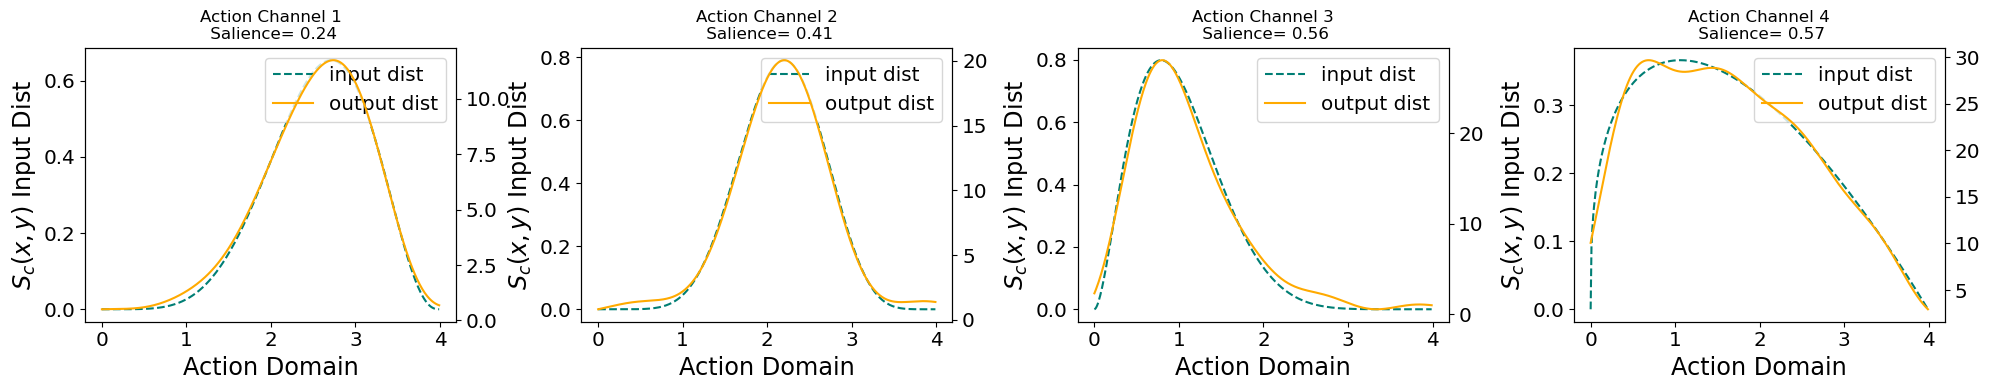

In [197]:
inp_dec = []
for i in range(n_actions):
    seg_in = data['bundle_ins'][i][-1] # Shape: (512, 1)
    inp_dec_uni = np.einsum('d,nd->n', seg_in, domain_phis)
    inp_dec.append(inp_dec_uni)

#7). Plot N channel side by side, each with twin y axes
fig, axes = plt.subplots(
    1, n_actions,
    figsize=(5 * n_actions, 4),
    sharex=True
)

# If you only have one action, axes will not be a list
if n_actions == 1:
    axes = [axes]


for i, ax in enumerate(axes):
    # primary y-axis: input distribution
    ax.plot(domain.squeeze(), beta_distributions[i],
            ls='--', color="#007e74",
            label="input dist")
    ax.set_xlabel("Action Domain", fontsize="xx-large")
    ax.set_ylabel("$S_c(x,y)$ Input Dist", fontsize="xx-large")
    ax.tick_params(axis='x', labelsize='x-large')
    ax.tick_params(axis='y', labelsize='x-large')

    # secondary y-axis: output distribution
    ax2 = ax.twinx()
    ax2.plot(domain.squeeze(), inp_dec[i],
             ls='-', color="#ffaa00",
             label="output dist")
    ax2.tick_params(axis='y', labelsize='x-large')

    # combined legend
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = ax2.get_legend_handles_labels()
    ax.legend(h1 + h2, l1 + l2,
              loc='upper right', fontsize='x-large')
    ax.set_title(f'Action Channel {i + 1}\n Salience={salience[i]: .2f}')

plt.tight_layout()
plt.savefig("./figures/bgmodel/bg_input.png")
plt.show()



### D1 & D2 DNF 

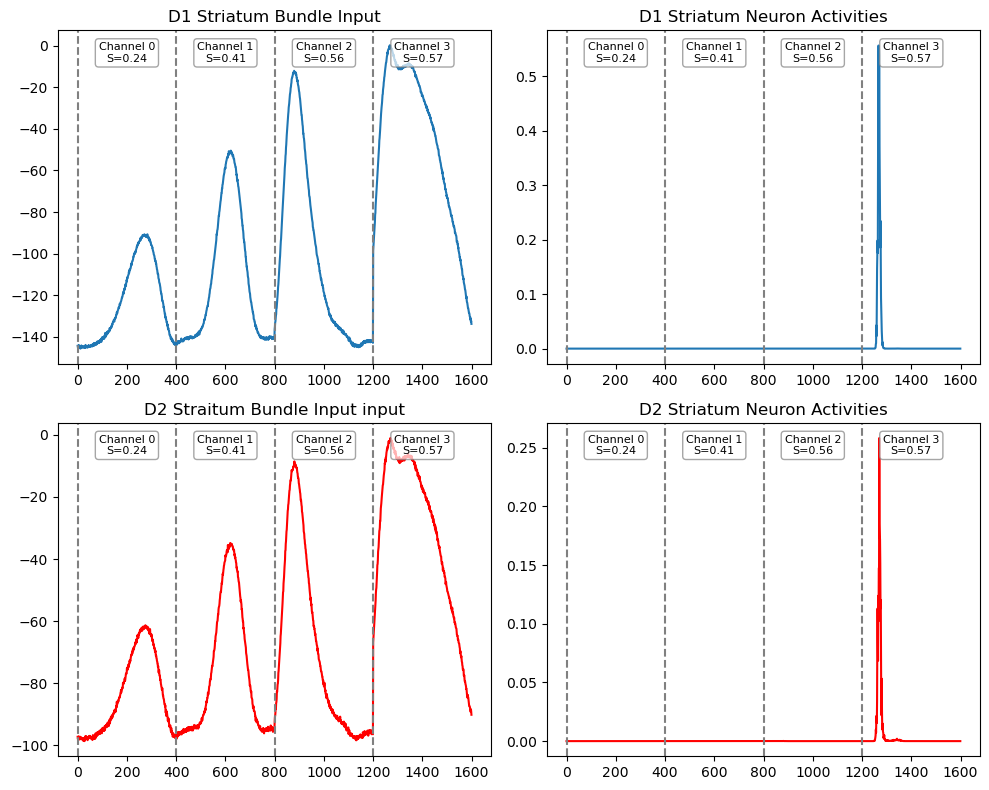

In [198]:

fig, axes = plt.subplots(2, 2, figsize=(10, 8),)
# D1
# D1 Input to DNF
axes[0,0].plot(data['d1_input'][-1])
axes[0,0].set_title("D1 Striatum Bundle Input")
# D1 Neuron Activities
axes[0,1].plot(data['d1_neuron'][-1])
axes[0,1].set_title("D1 Striatum Neuron Activities" )

# D2
# D2 Input to DNF
axes[1,0].plot(data['d2_input'][-1], color='red')
axes[1,0].set_title("D2 Straitum Bundle Input input")
# D2 Neuron activities 
axes[1,1].plot(data['d2_neuron'][-1], color ='red')
axes[1,1].set_title("D2 Striatum Neuron Activities" )

# --- Add separation lines and labels ---
for ax in axes.ravel():
    ylim = ax.get_ylim()
    y_label = ylim[0] + (ylim[1] - ylim[0]) * 0.90  # 5% above baseline (consistent placement)

    for i in range(n_actions):
        xpos = i * domain.shape[0]
        ax.axvline(x=xpos, linestyle='--', color='grey')

        # Compute center of the current channel
        if i < n_actions - 1:
            xmid = xpos + domain.shape[0] / 2
        else:
            xmax = len(data['d1_input'][-1])
            xmid = xpos + (xmax - xpos) / 2

        # Add consistent text labels
        ax.text(
            xmid, y_label,
            f"Channel {i}\nS={salience[i]:.2f}",
            ha="center", va="bottom", fontsize=8, color="black",
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="grey", alpha=0.7)
        )

plt.tight_layout()
plt.savefig("./figures/bgmodel/bg_dnf.png")
plt.show()


### Input Vs. Output Distribution

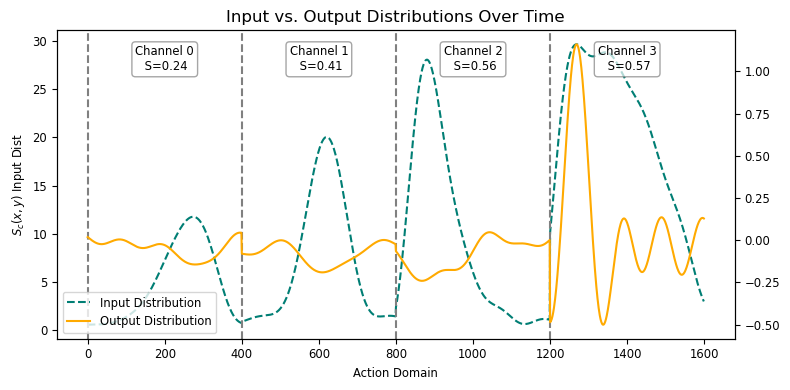

In [199]:
# Convert 512D SSP to Bundle 
output = []
for i_out in range(n_actions):
    seg = data['bundle_out'][-1][i_out * 512: (i_out + 1) * 512]
    seg_b = np.einsum('n,cn->c', seg, domain_phis)
    output.append(seg_b)

# hstack 
output_data = np.hstack(output)
input_data = np.hstack(inp_dec)

fig, ax = plt.subplots(figsize=(8, 4))
# Primary y-axis: input distribution
ax.plot(input_data,
        ls='--', color="#007e74",
        label="Input Distribution")
ax.set_xlabel("Action Domain", fontsize="small")
ax.set_ylabel('$S_c(x,y)$ Input Dist',
              fontsize='small', rotation=90,
              labelpad=10, va='center')
ax.tick_params(axis='x', labelsize='small')
ax.tick_params(axis='y', labelsize='small')

# Secondary y-axis: output distribution
ax2 = ax.twinx()
ax2.plot(output_data,
            ls='-', color="#ffaa00",
            label="Output Distribution")
ax2.tick_params(axis='y', labelsize='small')

# Combined legend
h1, l1 = ax.get_legend_handles_labels()
h2, l2 = ax2.get_legend_handles_labels()
ax.legend(h1 + h2, l1 + l2,
            loc='lower left', fontsize='small')
ax.set_title(f'Input vs. Output Distributions Over Time', fontsize="large")
 
# Channel separation lines + labels
for n in range(n_actions):
    xpos = n * domain.shape[0]
    ax.axvline(xpos, linestyle='--', color='gray')

    # Compute midpoint for text label
    if n < n_actions - 1:
        next_xpos = (n + 1) * domain.shape[0]
        x_text = (xpos + next_xpos) / 2
    else:
        x_text = xpos + domain.shape[0] / 2

    # Place text inside the plot region (on primary y-axis scale)
    y_text = ax.get_ylim()[1] * 0.95
    ax.text(
        x_text, y_text,
        f"Channel {n}\n S={salience[n]:.2f}",
        ha='center', va='top',
        fontsize='small',
        bbox=dict(boxstyle="round,pad=0.3",
                    fc="white", ec="gray", alpha=0.7)
    )

plt.tight_layout()
plt.savefig("./figures/bgmodel/bg_output.png")
plt.show()
